# IoT Traffic Analysis — Experimental (ML device types + DL header masking)

This notebook is a **safe experimental copy** that keeps your original structure (flows ML vs pcaps DL),
and adds:

1) **ML (flow-based) experiment** using **hardcoded device→type labels**  
2) **DL (packet-by-packet) experiment** in two variants:
   - **DL-RAW**: original (first `MAX_LEN` bytes of packet)
   - **DL-MASKED**: removes identity leakage by **stripping L2 (MAC)** and **masking IPs + ports** before extracting bytes

Plots:
- **Plot A**: ML vs DL-RAW (similar to your original notebook)
- **Plot B**: DL-RAW vs DL-MASKED (new, separate plot)


In [1]:
# 1) Imports & configuration
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier

# DL
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# PCAP
from scapy.all import rdpcap, Ether, IP, TCP, UDP

RANDOM_STATE = 43

# Dataset paths (edit to your local structure)
FLOW_DATA_GLOB = "unsw-dataset/flows/*.csv"
PCAP_DATA_GLOB = "unsw-dataset/pcaps/*.pcap"

# Sampling (recommended on 16GB RAM)
CANTIDAD_META_FLOWS = 250000   # None loads all (can be very large)
CANTIDAD_META_PKTS = 100000    # cap total packets used across all pcaps (DL)

# Flow leakage drop list (keep aligned with your earlier work)
DROP_COLS = ['time','srcMac','dstMac','ethType','srcIp','dstIp','ipProto','srcPort','dstPort','flowSeqNum']

# DL params
MAX_LEN = 500  # first bytes per packet
BATCH_SIZE = 512
EPOCHS = 3     # increase later


2026-01-11 20:55:40.153427: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-11 20:55:40.724998: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-11 20:55:43.947221: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2) Flow-based ML — device type labels

In [2]:
# 2a) Load flow CSVs with sampling during load (memory-friendly)
file_paths = glob.glob(FLOW_DATA_GLOB)
if not file_paths:
    raise FileNotFoundError(f"No flow CSVs found for pattern: {FLOW_DATA_GLOB}")

n_files = len(file_paths)
target = CANTIDAD_META_FLOWS
per_file_quota = None if target is None else max(1, target // n_files)

df_list = []
total_loaded = 0

for fp in file_paths:
    device_name = os.path.basename(fp).replace("_flows.csv", "")
    df_full = pd.read_csv(fp, low_memory=False)
    if per_file_quota is None:
        df = df_full
    else:
        df = df_full.sample(n=min(len(df_full), per_file_quota), random_state=RANDOM_STATE)
    df["device"] = device_name
    df_list.append(df)
    total_loaded += len(df)
    print(f"{device_name}: loaded {len(df):,} flows (running total {total_loaded:,})")

df_all = pd.concat(df_list, ignore_index=True)
print(f"Total flows loaded: {len(df_all):,} from {df_all['device'].nunique()} devices.")
display(df_all.head())


TPLinkSmartPlug_50c7bf005639: loaded 9,259 flows (running total 9,259)
WithingsSmartScale_0024e41b6f96: loaded 1,530 flows (running total 10,789)
SamsungCamera_00166cab6b88: loaded 9,259 flows (running total 20,048)
NetatmoWelcome_70ee50183443: loaded 9,259 flows (running total 29,307)
BelkinCamera_b4750eece5a9: loaded 9,259 flows (running total 38,566)
AugustDoorBell_e076d03f00ae: loaded 9,259 flows (running total 47,825)
CanaryCamera_7c70bc5d5edc: loaded 6,598 flows (running total 54,423)
PixStarPhotoFrame_e076d033bb85: loaded 9,259 flows (running total 63,682)
WithingsBabyMonitor_0024e41118a8: loaded 9,259 flows (running total 72,941)
BlipCareBPMeter_746a89002e25: loaded 54 flows (running total 72,995)
PhilipsHue_0017882b9a25: loaded 9,259 flows (running total 82,254)
SamsungSmartThings_d052a800675e: loaded 9,259 flows (running total 91,513)
NestDropCam_308cfb2fe4b2: loaded 2,108 flows (running total 93,621)
HelloBarbie_28c2ddffa52d: loaded 150 flows (running total 93,771)
LiFXBulb_

,time,srcMac,dstMac,ethType,srcIp,dstIp,ipProto,srcPort,dstPort,flowSeqNum,...,flowDuration,srcAvgInterarrivalTime,dstAvgInterarrivalTime,avgInterarrivalTime,srcStdDevInterarrivalTime,dstStdDevInterarrivalTime,stdDevInterarrivalTime,allMatchedProtocols,protocol,device
0,2016-11-27 04:45:26.999412,NaN,NaN,0x0800,192.168.1.228,54.251.165.219,6,37159,50443,7,...,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none,TPLinkSmartPlug_50c7bf005639
1,2016-10-06 18:48:34.352916,NaN,NaN,0x0800,192.168.1.227,54.254.250.149,6,54335,50443,23,...,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none,TPLinkSmartPlug_50c7bf005639
2,2016-11-29 16:16:03.813029,NaN,NaN,0x0800,192.168.1.228,54.251.165.219,6,34220,50443,24,...,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none,TPLinkSmartPlug_50c7bf005639
3,2016-11-21 23:25:39.500954,NaN,NaN,0x0800,192.168.1.228,54.254.250.149,6,46935,50443,24,...,144.0,0.0,0.0,144.0,0.0,0.0,0.0,none,none,TPLinkSmartPlug_50c7bf005639
4,2016-11-27 05:44:45.350687,NaN,NaN,0x0800,192.168.1.228,192.168.1.1,17,38060,53,1,...,21.0,0.0,0.0,21.0,0.0,0.0,0.0,dns|,dns,TPLinkSmartPlug_50c7bf005639


In [3]:
# 2b) Hardcoded device -> type mapping (edit if you change taxonomy)
device_to_type = {
    # camera / streamer
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    # sensors / meters
    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    # actuators / lights / plugs
    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    # hubs / infra
    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    # media / interactive
    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

df_all["device_type"] = df_all["device"].map(device_to_type)

missing = df_all.loc[df_all["device_type"].isna(), "device"].unique()
print("Devices missing mapping:", missing)

print("\nType distribution (flows):")
display(df_all["device_type"].value_counts(dropna=False).to_frame("n_flows"))


Devices missing mapping: []

Type distribution (flows):


,n_flows
device_type,
camera_streamer,65365
sensor_meter,43026
media_speaker_display,37186
actuator_light_plug,37036
hub_gateway_bridge,18518


In [4]:
# 2c) Train ML classifier on flows -> device_type (group split by device)
df_labeled = df_all.dropna(subset=["device_type"]).copy()

cols_to_drop = [c for c in DROP_COLS if c in df_labeled.columns]
X = df_labeled.drop(columns=cols_to_drop + ["device", "device_type"], errors="ignore")
y = df_labeled["device_type"].astype(str)
groups = df_labeled["device"]

# NOTE: categorical features can hurt generalization across unseen devices.
# Start numeric-only. If you want categoricals, set USE_OHE=True.
USE_OHE = False

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist() if USE_OHE else []
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ("scale", StandardScaler(), num_cols),
], remainder="drop")

clf = ExtraTreesClassifier(
    n_estimators=400,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample"
)

pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", clf),
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train devices:", df_labeled.iloc[train_idx]["device"].nunique())
print("Test devices :", df_labeled.iloc[test_idx]["device"].nunique())
print("Train flows  :", len(train_idx))
print("Test flows   :", len(test_idx))

t0 = time.time()
pipeline.fit(X_train, y_train)
ml_train_time = time.time() - t0

y_pred = pipeline.predict(X_test)
ml_acc = accuracy_score(y_test, y_pred)
ml_f1 = f1_score(y_test, y_pred, average="macro")

print(f"ML Accuracy: {ml_acc:.4f}")
print(f"ML Macro F1: {ml_f1:.4f}")
print(f"ML Train time: {ml_train_time:.2f}s")

print("\nClassification report (ML):")
print(classification_report(y_test, y_pred))


Train devices: 18
Test devices : 9
Train flows  : 129666
Test flows   : 71465
ML Accuracy: 0.2150
ML Macro F1: 0.1235
ML Train time: 22.04s

Classification report (ML):
                       precision    recall  f1-score   support

  actuator_light_plug       0.11      0.03      0.05     18518
      camera_streamer       0.26      0.81      0.39     15857
   hub_gateway_bridge       0.00      0.00      0.00      9259
media_speaker_display       0.41      0.10      0.17     18518
         sensor_meter       0.01      0.01      0.01      9313

             accuracy                           0.22     71465
            macro avg       0.16      0.19      0.12     71465
         weighted avg       0.19      0.22      0.14     71465



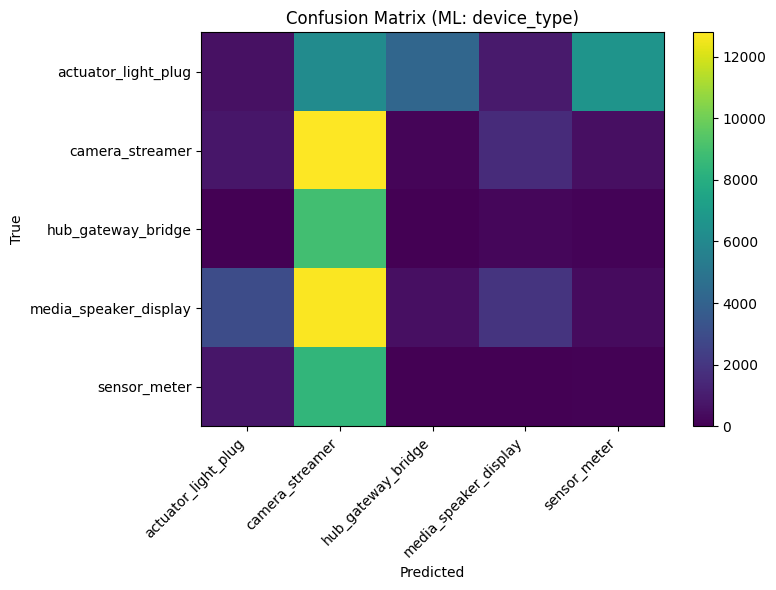

In [5]:
# 2d) Confusion matrix (ML)
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8,6))
plt.imshow(cm, aspect='auto')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.title("Confusion Matrix (ML: device_type)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 3) Packet-based DL — RAW vs MASKED bytes

In [6]:
# 3a) Helpers: packet -> byte vector (RAW or MASKED)
def packet_to_bytes(pkt, max_len=500, masked=False):
    try:
        p = pkt

        if masked:
            # Strip Ethernet (removes MACs)
            if p.haslayer(Ether):
                p = p.payload

            # Mask IP addresses
            if p.haslayer(IP):
                p[IP].src = "0.0.0.0"
                p[IP].dst = "0.0.0.0"
                if hasattr(p[IP], "chksum"):
                    del p[IP].chksum

            # Mask ports (TCP/UDP)
            if p.haslayer(TCP):
                p[TCP].sport = 0
                p[TCP].dport = 0
                if hasattr(p[TCP], "chksum"):
                    del p[TCP].chksum
            if p.haslayer(UDP):
                p[UDP].sport = 0
                p[UDP].dport = 0
                if hasattr(p[UDP], "chksum"):
                    del p[UDP].chksum

        b = bytes(p)
        arr = np.frombuffer(b, dtype=np.uint8)
        if len(arr) >= max_len:
            arr = arr[:max_len]
        else:
            arr = np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=0)
        return arr
    except Exception:
        return None

def load_packets_from_pcaps(pcap_glob, max_len=500, max_total_packets=None, masked=False):
    files = glob.glob(pcap_glob)
    if not files:
        raise FileNotFoundError(f"No pcaps found for pattern: {pcap_glob}")

    X_list, y_list = [], []
    total = 0

    for fp in files:
        device_name = os.path.basename(fp).replace(".pcap", "")
        pkts = rdpcap(fp)
        for pkt in pkts:
            arr = packet_to_bytes(pkt, max_len=max_len, masked=masked)
            if arr is None:
                continue
            X_list.append(arr)
            y_list.append(device_name)
            total += 1
            if max_total_packets is not None and total >= max_total_packets:
                break
        print(f"{device_name}: packets kept so far {total:,}")
        if max_total_packets is not None and total >= max_total_packets:
            break

    X = np.stack(X_list, axis=0).astype(np.float32) / 255.0
    y = np.array(y_list)
    return X, y


In [ ]:
# 3b) Build DL dataset (RAW)
X_raw, y_raw = load_packets_from_pcaps(
    PCAP_DATA_GLOB,
    max_len=MAX_LEN,
    max_total_packets=CANTIDAD_META_PKTS,
    masked=False
)

# Encode labels
classes = sorted(np.unique(y_raw))
class_to_idx = {c:i for i,c in enumerate(classes)}
y_raw_idx = np.array([class_to_idx[c] for c in y_raw], dtype=np.int64)

# Train/test split (packet-level baseline, like your original)
from sklearn.model_selection import train_test_split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_raw_idx, test_size=0.30, random_state=RANDOM_STATE, stratify=y_raw_idx
)

# Expand dims for Conv1D
Xr_train = np.expand_dims(Xr_train, axis=-1)
Xr_test  = np.expand_dims(Xr_test, axis=-1)

print("RAW train:", Xr_train.shape, "test:", Xr_test.shape, "classes:", len(classes))


In [ ]:
# 3c) Train DL model (RAW)
def make_cnn(max_len=500, n_classes=10):
    model = Sequential([
        Conv1D(64, 3, activation="relu", input_shape=(max_len, 1)),
        MaxPooling1D(2),
        Conv1D(128, 3, activation="relu"),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

dl_raw = make_cnn(MAX_LEN, len(classes))

t0 = time.time()
hist_raw = dl_raw.fit(
    Xr_train, yr_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
dl_raw_train_time = time.time() - t0

raw_loss, raw_acc = dl_raw.evaluate(Xr_test, yr_test, verbose=0)
print(f"DL-RAW Accuracy: {raw_acc:.4f}")
print(f"DL-RAW Train time: {dl_raw_train_time:.2f}s")


In [ ]:
# 3d) Build DL dataset (MASKED: strip MAC + mask IPs + mask ports)
X_mask, y_mask = load_packets_from_pcaps(
    PCAP_DATA_GLOB,
    max_len=MAX_LEN,
    max_total_packets=CANTIDAD_META_PKTS,
    masked=True
)

# Reuse same label space as RAW
y_mask_idx = np.array([class_to_idx.get(c, -1) for c in y_mask], dtype=np.int64)
keep = y_mask_idx >= 0
X_mask = X_mask[keep]
y_mask_idx = y_mask_idx[keep]

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mask, y_mask_idx, test_size=0.30, random_state=RANDOM_STATE, stratify=y_mask_idx
)

Xm_train = np.expand_dims(Xm_train, axis=-1)
Xm_test  = np.expand_dims(Xm_test, axis=-1)

print("MASKED train:", Xm_train.shape, "test:", Xm_test.shape)


In [ ]:
# 3e) Train DL model (MASKED)
dl_masked = make_cnn(MAX_LEN, len(classes))

t0 = time.time()
hist_mask = dl_masked.fit(
    Xm_train, ym_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
dl_mask_train_time = time.time() - t0

mask_loss, mask_acc = dl_masked.evaluate(Xm_test, ym_test, verbose=0)
print(f"DL-MASKED Accuracy: {mask_acc:.4f}")
print(f"DL-MASKED Train time: {dl_mask_train_time:.2f}s")


## 4) Plots (keep original DL plot + add a new masked-vs-raw plot)

In [ ]:
# Plot A: ML vs DL-RAW (similar to your original comparison)
labelsA = ["ML (flows)", "DL-RAW (pcaps)"]
accA = [ml_acc, raw_acc]
timeA = [ml_train_time, dl_raw_train_time]

plt.figure()
plt.bar(labelsA, accA)
plt.ylabel("Accuracy")
plt.title("Comparison (original-style): ML vs DL-RAW")
plt.show()

plt.figure()
plt.bar(labelsA, timeA)
plt.ylabel("Train time (s)")
plt.title("Train time: ML vs DL-RAW")
plt.show()


In [ ]:
# Plot B (new): DL-RAW vs DL-MASKED (separate plot)
labelsB = ["DL-RAW", "DL-MASKED (no MAC/IP/ports)"]
accB = [raw_acc, mask_acc]
timeB = [dl_raw_train_time, dl_mask_train_time]

plt.figure()
plt.bar(labelsB, accB)
plt.ylabel("Accuracy")
plt.title("DL comparison: RAW vs MASKED bytes")
plt.show()

plt.figure()
plt.bar(labelsB, timeB)
plt.ylabel("Train time (s)")
plt.title("DL train time: RAW vs MASKED")
plt.show()
